Week One was linear regression with polynomials and VIF to predict multicollinearity.

In [2]:
import pandas as pd
import numpy as np

In [3]:
df_agriculture = pd.read_csv(r"C:\Users\thyde\Documents\OMDS Resources\DX 799 O1 Data Science Capstone\climate_change_impact_on_agriculture_2024 - climate_change_impact_on_agriculture_2024.csv")
df_usa_agr = df_agriculture[df_agriculture["Country"] == "USA"]
df_usa_agr_numeric = df_usa_agr.select_dtypes(include="number")
df_usa_agr_numeric.head()

,Year,Average Temperature (C),Total Precipitation (mm),CO2 Emissions (MT),Crop Yield (MT per HA),Extreme Weather Events,Irrigation Access %,Pesticide Use (KG per HA),Fertilizer Use (KG per HA),Soil Health Index,Economic Impact (Million USD)
8968,2019,17.19,975.13,10.73,2.180,5,52.45,26.06,71.56,97.32,353.16
8969,2003,14.70,2272.28,11.45,2.500,9,57.37,19.48,46.13,77.32,1126.27
8970,1990,12.03,2704.89,3.86,2.450,8,54.67,13.10,2.56,50.75,1026.35
8971,2024,12.18,1647.58,19.10,1.872,8,36.61,43.15,22.46,52.18,925.79
8972,2023,30.62,1630.22,29.28,3.249,9,70.31,5.80,49.85,31.92,509.77


In [4]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt


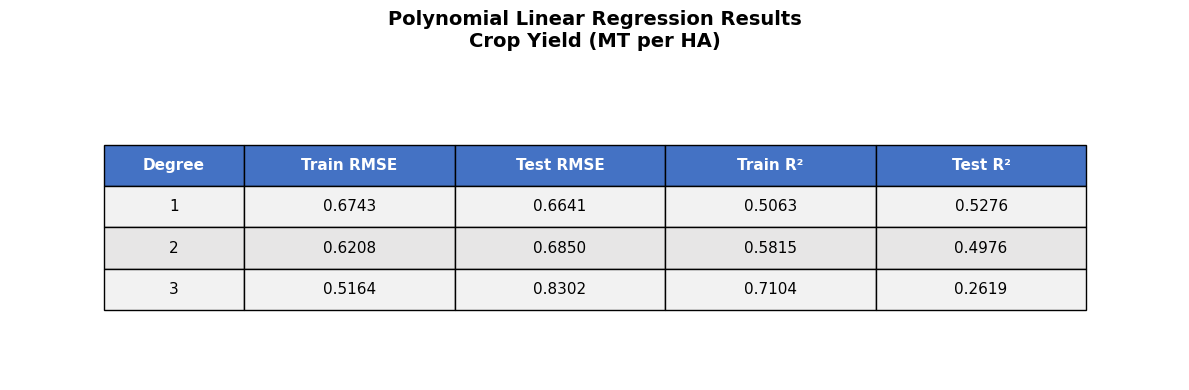


POLYNOMIAL LINEAR REGRESSION RESULTS
 Degree Train RMSE Test RMSE Train R² Test R²
      1     0.6743    0.6641   0.5063  0.5276
      2     0.6208    0.6850   0.5815  0.4976
      3     0.5164    0.8302   0.7104  0.2619


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# PREPARE DATA
y = df_usa_agr_numeric["Crop Yield (MT per HA)"]
X = df_usa_agr_numeric.drop(columns=["Crop Yield (MT per HA)"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# SCALE FEATURES
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# LOOP THROUGH DEGREES AND COLLECT RESULTS
degrees = [1, 2, 3]
results = []

for degree in degrees:
    # Create polynomial features from SCALED data
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)
    
    # Fit model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    # Make predictions
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    
    # Evaluate
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # Store results
    results.append({
        'Degree': int(degree),
        'Train RMSE': f'{train_rmse:.4f}',
        'Test RMSE': f'{test_rmse:.4f}',
        'Train R²': f'{train_r2:.4f}',
        'Test R²': f'{test_r2:.4f}'
    })

# CREATE RESULTS DATAFRAME
results_df = pd.DataFrame(results)

# PLOT TABLE WITH ax.table()
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('tight')
ax.axis('off')

# Create table
table = ax.table(
    cellText=results_df.values,
    colLabels=results_df.columns,
    cellLoc='center',
    loc='center',
    colWidths=[0.12, 0.18, 0.18, 0.18, 0.18]
)

# Format table style
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Color header row
for i in range(len(results_df.columns)):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(results_df) + 1):
    for j in range(len(results_df.columns)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#E7E6E6')
        else:
            table[(i, j)].set_facecolor('#F2F2F2')

plt.title('Polynomial Linear Regression Results\nCrop Yield (MT per HA)', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Print to console as well
print("\n" + "="*80)
print("POLYNOMIAL LINEAR REGRESSION RESULTS")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

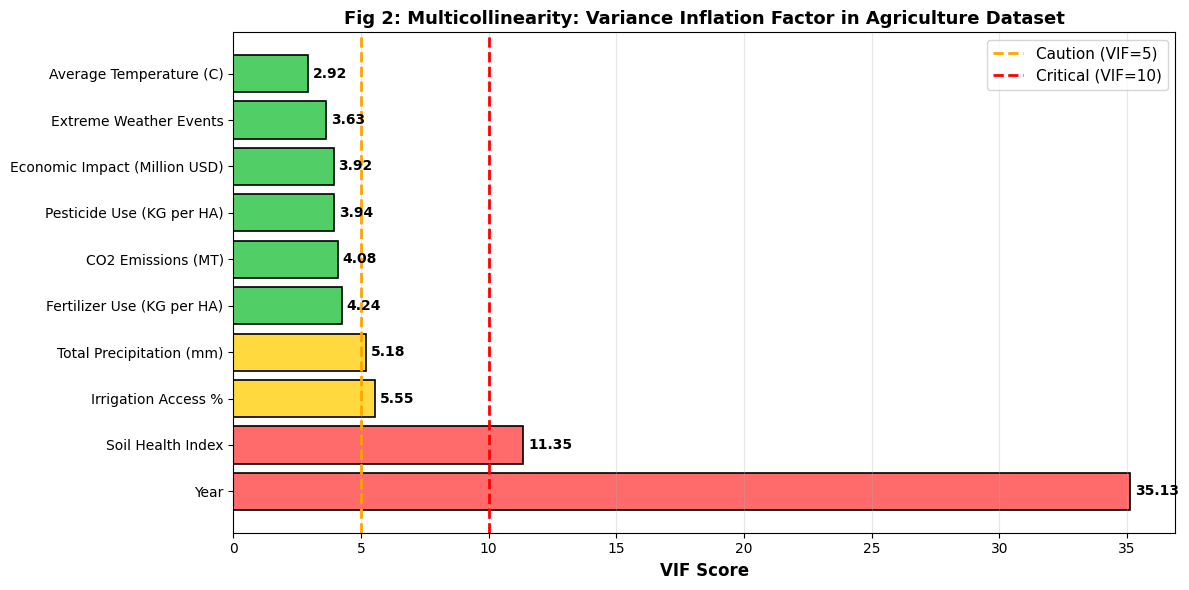

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# CALCULATE VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

# CREATE BAR PLOT
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#FF6B6B' if v > 10 else '#FFD93D' if v > 5 else '#51CF66' 
          for v in vif_data['VIF']]

bars = ax.barh(vif_data['Feature'], vif_data['VIF'], color=colors, edgecolor='black', linewidth=1.2)

# Add threshold lines
ax.axvline(x=5, color='orange', linestyle='--', linewidth=2, label='Caution (VIF=5)')
ax.axvline(x=10, color='red', linestyle='--', linewidth=2, label='Critical (VIF=10)')

# Add value labels on bars
for i, (feature, vif) in enumerate(zip(vif_data['Feature'], vif_data['VIF'])):
    ax.text(vif + 0.2, i, f'{vif:.2f}', va='center', fontweight='bold')

ax.set_xlabel('VIF Score', fontsize=12, fontweight='bold')
ax.set_title('Fig 2: Multicollinearity: Variance Inflation Factor in Agriculture Dataset', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
df_CO2 = pd.read_csv(r"C:\Users\thyde\Documents\OMDS Resources\DX 799 O1 Data Science Capstone\owid-co2-data.csv")
numeric_df_CO2 = df_CO2.select_dtypes(include='number') 
nona_numeric_df_CO2 = numeric_df_CO2.dropna()
clean_numeric_dfCO2 = nona_numeric_df_CO2[['gdp','co2_growth_prct','co2_per_capita','co2_per_gdp','temperature_change_from_co2']].copy()
clean_numeric_dfCO2.head()

,gdp,co2_growth_prct,co2_per_capita,co2_per_gdp,temperature_change_from_co2
3644,4.641366e+11,8.263,16.236,0.599,0.008
3645,4.613021e+11,0.495,16.103,0.606,0.008
3646,4.786337e+11,1.788,16.208,0.594,0.008
3647,5.015248e+11,1.528,16.294,0.576,0.008
3648,5.279932e+11,1.674,16.405,0.556,0.008


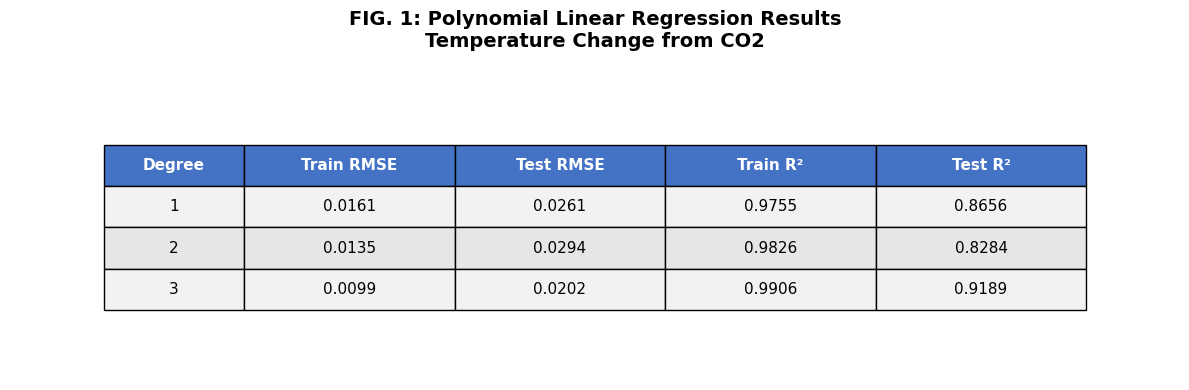


Fig. 1: POLYNOMIAL LINEAR REGRESSION RESULTS
 Degree Train RMSE Test RMSE Train R² Test R²
      1     0.0161    0.0261   0.9755  0.8656
      2     0.0135    0.0294   0.9826  0.8284
      3     0.0099    0.0202   0.9906  0.9189


In [8]:
y = clean_numeric_dfCO2["temperature_change_from_co2"]
X = clean_numeric_dfCO2.drop(columns=["temperature_change_from_co2"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# SCALE FEATURES
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# LOOP THROUGH DEGREES AND COLLECT RESULTS
degrees = [1, 2, 3]
results = []

for degree in degrees:
    # Create polynomial features from SCALED data
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)
    
    # Fit model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    # Make predictions
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    
    # Evaluate
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # Store results
    results.append({
        'Degree': int(degree),
        'Train RMSE': f'{train_rmse:.4f}',
        'Test RMSE': f'{test_rmse:.4f}',
        'Train R²': f'{train_r2:.4f}',
        'Test R²': f'{test_r2:.4f}'
    })

# CREATE RESULTS DATAFRAME
results_df = pd.DataFrame(results)

# PLOT TABLE WITH ax.table()
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('tight')
ax.axis('off')

# Create table
table = ax.table(
    cellText=results_df.values,
    colLabels=results_df.columns,
    cellLoc='center',
    loc='center',
    colWidths=[0.12, 0.18, 0.18, 0.18, 0.18]
)

# Format table style
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Color header row
for i in range(len(results_df.columns)):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(results_df) + 1):
    for j in range(len(results_df.columns)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#E7E6E6')
        else:
            table[(i, j)].set_facecolor('#F2F2F2')

plt.title('FIG. 1: Polynomial Linear Regression Results\nTemperature Change from CO2', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Print to console as well
print("\n" + "="*80)
print("Fig. 1: POLYNOMIAL LINEAR REGRESSION RESULTS")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

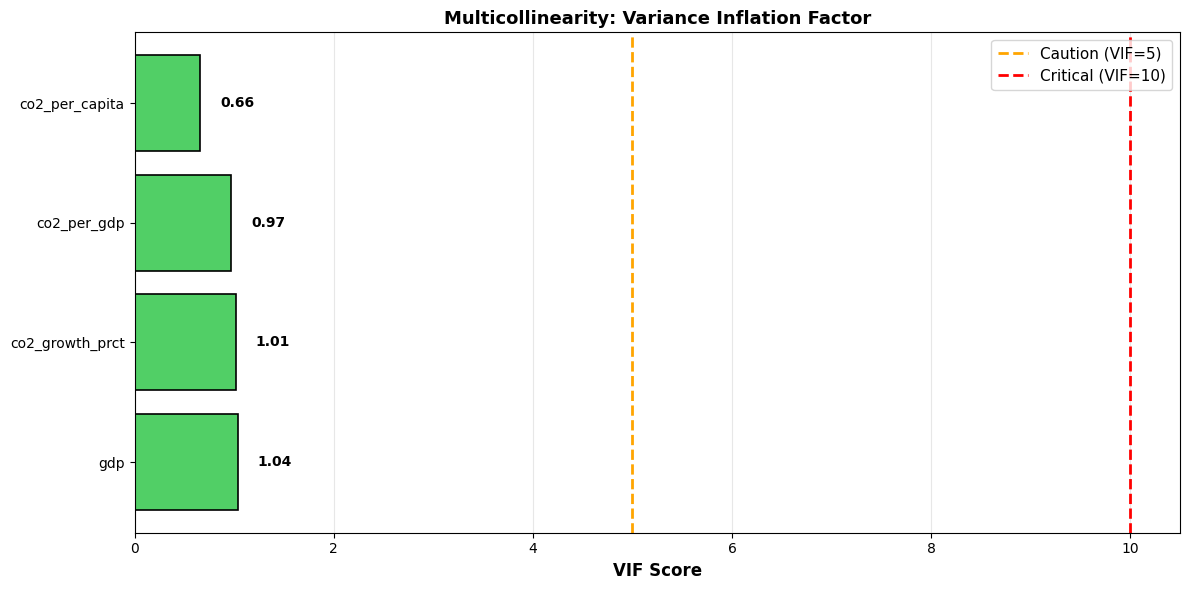

In [9]:
# CALCULATE VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

# CREATE BAR PLOT
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#FF6B6B' if v > 10 else '#FFD93D' if v > 5 else '#51CF66' 
          for v in vif_data['VIF']]

bars = ax.barh(vif_data['Feature'], vif_data['VIF'], color=colors, edgecolor='black', linewidth=1.2)

# Add threshold lines
ax.axvline(x=5, color='orange', linestyle='--', linewidth=2, label='Caution (VIF=5)')
ax.axvline(x=10, color='red', linestyle='--', linewidth=2, label='Critical (VIF=10)')

# Add value labels on bars
for i, (feature, vif) in enumerate(zip(vif_data['Feature'], vif_data['VIF'])):
    ax.text(vif + 0.2, i, f'{vif:.2f}', va='center', fontweight='bold')

ax.set_xlabel('VIF Score', fontsize=12, fontweight='bold')
ax.set_title('Multicollinearity: Variance Inflation Factor', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()